embeddings de palavras com dados do #edtwt

In [2]:
%pip install pandas numpy seaborn matplotlib plotly scikit-learn gensim nltk spacy nbformat>=4.2.0 --quiet

zsh:1: 4.2.0 not found
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import ast
import json
import os
import nltk

from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
nltk.download('punkt_tab', quiet=True)

sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

word2vec

carregamento dos dados

In [4]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, '..', 'entregas', 'p3', 'entrega_3.csv')
json_path = os.path.join(DATA_DIR, '..', 'entregas', 'p3', 'entrega_3_word2vec_features.json')

for p in [csv_path, json_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

In [5]:
df = pd.read_csv(csv_path)
print(f"Dataset: {df.shape[0]} tweets, {df.shape[1]} colunas")
print(f"Colunas: {list(df.columns)}")
df[['text', 'normalizacao_re', 'tokens_word2vec', 'vetor_medio_word2vec']].head()

Dataset: 2815 tweets, 35 colunas
Colunas: ['search_date', 'id', 'url', 'text', 'source', 'created_at', 'lang', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'view_count', 'bookmark_count', 'conversation_id', 'in_reply_to_id', 'in_reply_to_user_id', 'in_reply_to_username', 'is_reply', 'is_limited_reply', 'author_id', 'author_name', 'author_username', 'author_url', 'author_followers', 'author_following', 'hashtags', 'urls', 'mentions', 'tokenizacao_nltk', 'remocao_stopwords_spacy', 'stemming_nltk', 'normalizacao_re', 'features_tfidf_sklearn', 'tokens_word2vec', 'vetor_medio_word2vec']


,text,normalizacao_re,tokens_word2vec,vetor_medio_word2vec
0,Refeições de hj! #wieiad ₍ᐢ. .ᐢ₎\n．☆．。．:*･ﾟ\n\...,refeiçõ hj wieiad gent esquec tir fot almoc ar...,"[""refeiçõ"", ""hj"", ""wieiad"", ""gent"", ""esquec"", ...","[-0.112007, 0.145861, -0.010249, 0.117236, 0.0..."
1,em quanto tempo vocês tiveram resultados notáv...,result not academ edtwt gymtwt gymgirl,"[""result"", ""not"", ""academ"", ""edtwt"", ""gymtwt"",...","[-0.06753, 0.086301, -0.005118, 0.073525, 0.00..."
2,A geladeira do edtwt que mora sozinha \n#edtwt...,geladeir edtwt mor sozinh edtwt nofood diet ze...,"[""geladeir"", ""edtwt"", ""mor"", ""sozinh"", ""edtwt""...","[-0.135215, 0.175155, -0.010368, 0.140096, 0.0..."
3,"Talvez, só talvez eu tenha dismofia corporal. ...",tenh dismof corporal amig jur q tính corp vei ...,"[""tenh"", ""dismof"", ""corporal"", ""amig"", ""jur"", ...","[-0.122911, 0.159895, -0.010451, 0.134275, 0.0..."
4,"cade a comunidade #edtwt ? quwro amizades, vam...",cad comun edtwt quwr amizad vam motiv bbzud,"[""cad"", ""comun"", ""edtwt"", ""quwr"", ""amizad"", ""v...","[-0.074613, 0.097484, -0.009679, 0.080022, 0.0..."


In [6]:
with open(json_path, 'r') as f:
    w2v_config = json.load(f)

print('configuração do modelo word2vec original:')
for k, v in w2v_config.items():
    if k != 'vocabulario_amostra':
        print(f"  {k}: {v}")

configuração do modelo word2vec original:
  vocabulario_tamanho: 5840
  vector_size: 100
  window: 5
  min_count: 1
  sg: 0
  arquitetura: CBOW


extração e diagnóstico dos vetores

In [7]:
def parse_vetor(vetor_str):
    if pd.isna(vetor_str):
        return None
    try:
        return np.array(ast.literal_eval(vetor_str), dtype=np.float32)
    except (ValueError, SyntaxError):
        return None

def parse_tokens(token_str):
    if pd.isna(token_str):
        return []
    try:
        result = ast.literal_eval(token_str)
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

df['vetor_parsed'] = df['vetor_medio_word2vec'].apply(parse_vetor)
df['tokens_parsed'] = df['tokens_word2vec'].apply(parse_tokens)

valid_mask = df['vetor_parsed'].notna()
vetores = np.stack(df.loc[valid_mask, 'vetor_parsed'].values)
documentos = df.loc[valid_mask, 'text'].values
tokens_lista = df.loc[valid_mask, 'tokens_parsed'].values

print(f"Vetores carregados: {vetores.shape}")
print(f"Dimensão de cada vetor: {vetores.shape[1]}")
print(f"Total de documentos válidos: {len(documentos)}")

Vetores carregados: (2815, 100)
Dimensão de cada vetor: 100
Total de documentos válidos: 2815


In [8]:
sim_raw = cosine_similarity(vetores)
upper_raw = sim_raw[np.triu_indices_from(sim_raw, k=1)]

print('=== Similaridade de Cosseno ORIGINAL (sem centralização) ===')
print(f'  Média: {upper_raw.mean():.6f}')
print(f'  Desvio padrão: {upper_raw.std():.6f}')
print(f'  Mínimo: {upper_raw.min():.4f}  |  Máximo: {upper_raw.max():.4f}')
print(f'  Mediana: {np.median(upper_raw):.6f}')
print()
print('todos os valores estão muito próximos de 1.0, indicando que os vetores')
print('possuem um componente dominante comum (palavras frequentes compartilhadas).')
print('a similaridade direta não consegue distinguir documentos entre si.')

=== Similaridade de Cosseno ORIGINAL (sem centralização) ===
  Média: 0.999767
  Desvio padrão: 0.000394
  Mínimo: 0.9806  |  Máximo: 1.0000
  Mediana: 0.999817

todos os valores estão muito próximos de 1.0, indicando que os vetores
possuem um componente dominante comum (palavras frequentes compartilhadas).
a similaridade direta não consegue distinguir documentos entre si.


In [9]:
vetor_medio_global = vetores.mean(axis=0)
vetores_centralizados = vetores - vetor_medio_global

sim_cent = cosine_similarity(vetores_centralizados)
upper_cent = sim_cent[np.triu_indices_from(sim_cent, k=1)]

print('=== Similaridade de Cosseno CENTRALIZADA (após mean-centering) ===')
print(f'  Média: {upper_cent.mean():.6f}')
print(f'  Desvio padrão: {upper_cent.std():.6f}')
print(f'  Mínimo: {upper_cent.min():.4f}  |  Máximo: {upper_cent.max():.4f}')
print(f'  Mediana: {np.median(upper_cent):.6f}')
print()
print('após a centralização, a similaridade varia de -1 a +1 com')
print('distribuição centrada em 0, revelando as diferenças semânticas reais.')

=== Similaridade de Cosseno CENTRALIZADA (após mean-centering) ===
  Média: 0.002290
  Desvio padrão: 0.932912
  Mínimo: -0.9999  |  Máximo: 1.0000
  Mediana: 0.021035

após a centralização, a similaridade varia de -1 a +1 com
distribuição centrada em 0, revelando as diferenças semânticas reais.


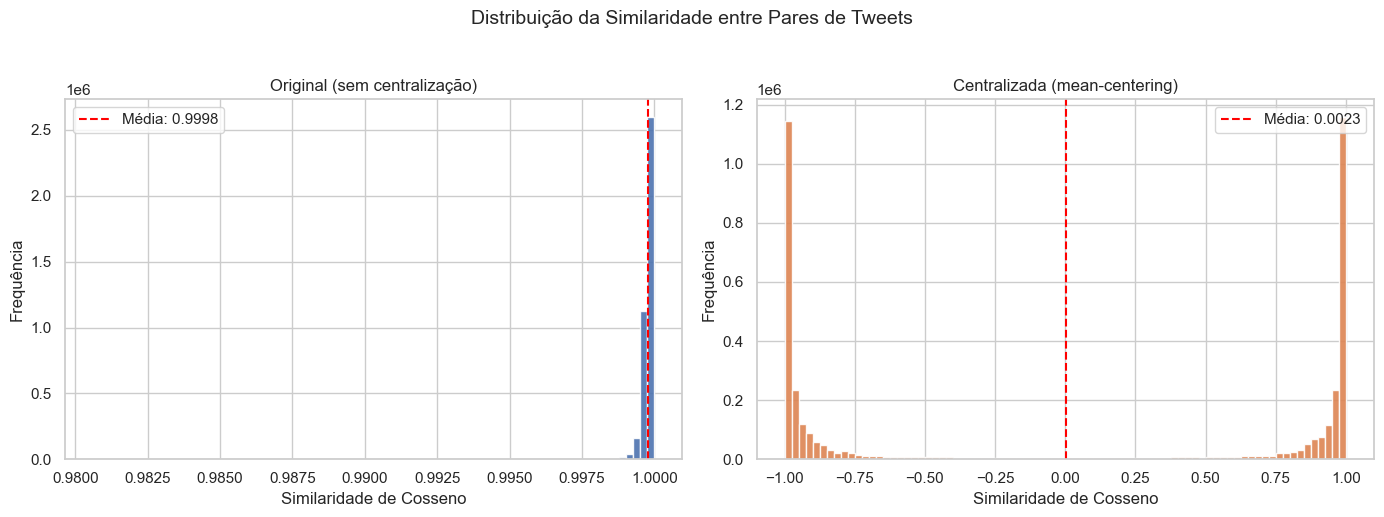

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(upper_raw, bins=80, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].axvline(upper_raw.mean(), color='red', linestyle='--', label=f'Média: {upper_raw.mean():.4f}')
axes[0].set_title('Original (sem centralização)', fontsize=12)
axes[0].set_xlabel('Similaridade de Cosseno')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].hist(upper_cent, bins=80, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].axvline(upper_cent.mean(), color='red', linestyle='--', label=f'Média: {upper_cent.mean():.4f}')
axes[1].set_title('Centralizada (mean-centering)', fontsize=12)
axes[1].set_xlabel('Similaridade de Cosseno')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('Distribuição da Similaridade entre Pares de Tweets', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

heatmap de similaridade centralizada (amostra)

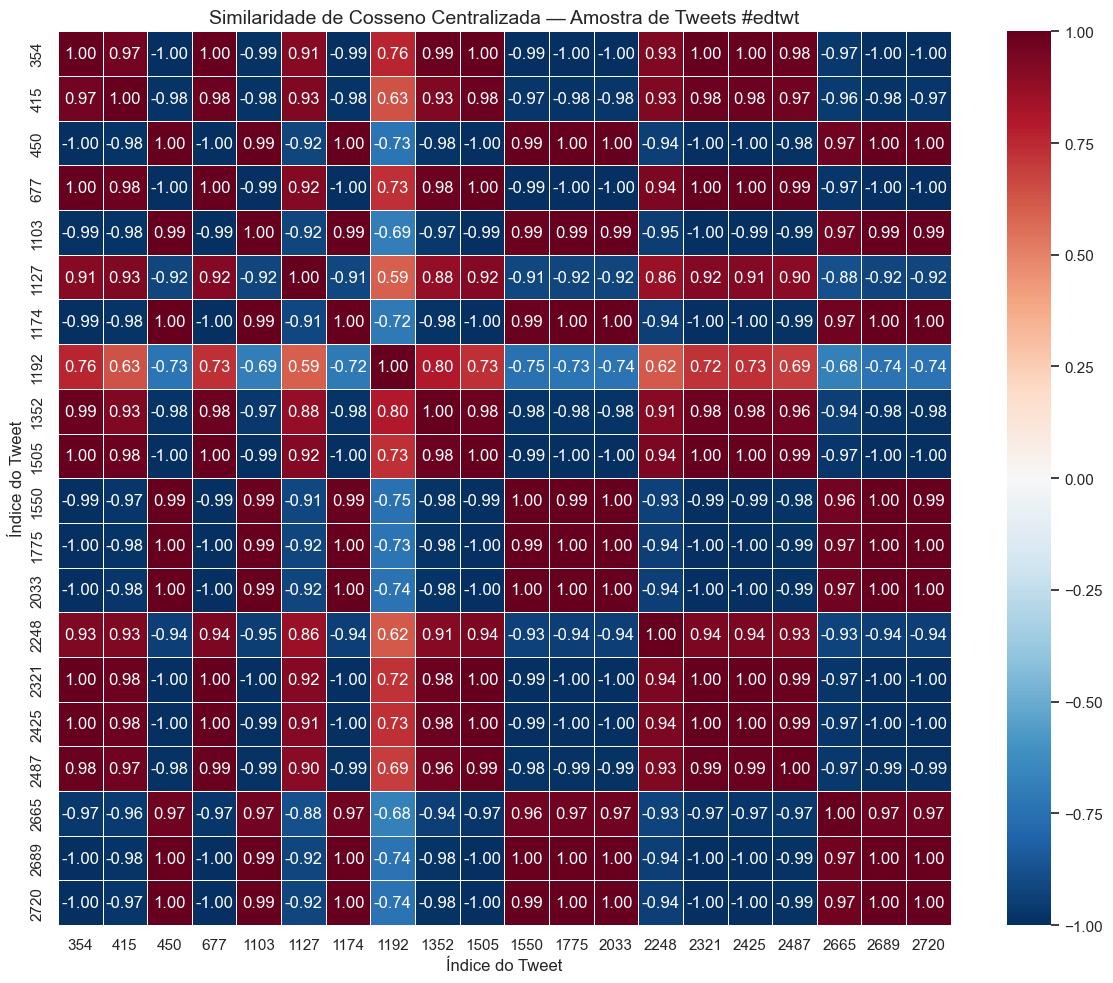

In [11]:
np.random.seed(42)
n_amostra = min(20, len(documentos))
indices_amostra = np.sort(np.random.choice(len(documentos), size=n_amostra, replace=False))

matriz_amostra = sim_cent[np.ix_(indices_amostra, indices_amostra)]
labels = [str(i) for i in indices_amostra]

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_amostra,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=.5,
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1, vmax=1
)
plt.title('Similaridade de Cosseno Centralizada — Amostra de Tweets #edtwt', fontsize=14)
plt.xlabel('Índice do Tweet', fontsize=12)
plt.ylabel('Índice do Tweet', fontsize=12)
plt.tight_layout()
plt.show()

verificar valores absolutos/extremos

In [12]:
print('tweets da amostra:\n')
for i in indices_amostra:
    texto = documentos[i].replace('\n', ' ')[:90]
    print(f'  [{i}] {texto}{"..." if len(documentos[i]) > 90 else ""}')

tweets da amostra:

  [354] Fui me pesar e tô com 77 kg #fatspo #feederism #edtwt https://t.co/haFNW9k57M
  [415] uma pequena dica não óbvia para muitos, se você ainda come demais, quando vc ta comendo, v...
  [450] Busco mutis otra vez  arriba los edgys #shedtwt #edtwt #obstwt de todo menos pedotwt o zot...
  [677] dando uma de #edtwt pq eu to com mt fome pra jantar mas já passei as calorias do dia hoje ...
  [1103] quando eu pensar em comer vou pensar nela, tão bebezinha, pequena e delicada, a winter é m...
  [1127] Eu so vou conseguir mudar m8nha vida de verdade quando eu for magra, porquê existem duas v...
  [1174] amigos do #edtwt indicação de site pra vocês (se vcs não conhecerem) tem vaaaarias receita...
  [1192] é galera, eu oficialmente entrei na casa dos 70 quilos, eu tô muito feliz 😭😭😭🫶🫶🫶🎉🎉 #edtwt ...
  [1352] Café da manhã💗 ~94 kcal &gt;&lt; #edtwt https://t.co/sONafkX4Yh
  [1505] @ryanmaluco vai ter #edtwt hoje
  [1550] vomitei meu almoço, posso fazer parte do #edtwt e ser

recomendação por similaridade semântica

In [13]:
model_w2v = Word2Vec(
    sentences=[t for t in tokens_lista if len(t) > 0],
    vector_size=w2v_config.get('vector_size', 100),
    window=w2v_config.get('window', 5),
    min_count=w2v_config.get('min_count', 1),
    workers=4,
    sg=w2v_config.get('sg', 0)
)
print(f"Modelo Word2Vec treinado com {len(model_w2v.wv.index_to_key)} palavras.")

Modelo Word2Vec treinado com 5840 palavras.


In [14]:
def buscar_tweets(consulta, model, documentos, vetores_cent, vetor_medio_global, num_resultados=10):
    tokens_busca = word_tokenize(consulta.lower())
    vetores_palavras = [model.wv[t] for t in tokens_busca if t in model.wv]

    if not vetores_palavras:
        print(f"Aviso: Nenhuma palavra de '{consulta}' encontrada no vocabulário.")
        print(f"Tokens buscados: {tokens_busca}")
        return pd.DataFrame({'Tweet': [], 'Similaridade': []})

    vetor_busca_bruto = np.mean(vetores_palavras, axis=0)
    vetor_busca_cent = vetor_busca_bruto - vetor_medio_global

    similaridades = cosine_similarity(vetor_busca_cent.reshape(1, -1), vetores_cent)[0]
    indices_ranqueados = np.argsort(similaridades)[::-1]

    pd.set_option('display.max_colwidth', None)

    resultados = pd.DataFrame({
        'Tweet': [documentos[i].replace('\n', ' ')[:1000] for i in indices_ranqueados[:num_resultados]],
        'Similaridade': similaridades[indices_ranqueados[:num_resultados]]
    })
    return resultados

termo = input("Digite os termos de busca: ")

resultados = buscar_tweets(termo, model_w2v, documentos, vetores_centralizados, vetor_medio_global)
if not resultados.empty:
    print(f'\nTop {len(resultados)} resultados para "{termo}":')
resultados

Aviso: Nenhuma palavra de 'emagrecer' encontrada no vocabulário.
Tokens buscados: ['emagrecer']


,Tweet,Similaridade


agrupamento (clustering) com kmeans

In [15]:
num_clusters = 5

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(vetores_centralizados)

df_cluster = pd.DataFrame({'Tweet': documentos, 'Cluster': kmeans.labels_})

print(f'Agrupamento com {num_clusters} clusters:\n')
for c in range(num_clusters):
    cluster = df_cluster[df_cluster['Cluster'] == c]
    print(f'  Cluster {c} ({len(cluster)} tweets):')
    for s in cluster['Tweet'].head(3):
        print(f'    - {s.replace(chr(10), " ")[:100]}')
    print()

Agrupamento com 5 clusters:

  Cluster 0 (511 tweets):
    - em quanto tempo vocês tiveram resultados notáveis na academia ?  #edtwt #gymtwt #gymgirl
    - cade a comunidade #edtwt ? quwro amizades, vamos nos motivas bbzudos !
    - oi pra quem nao sabe eu sou tarologa e quem der rt nessa thread ganha uma perguntinha de sim/nao com

  Cluster 1 (1058 tweets):
    - Refeições de hj! #wieiad ₍ᐢ. .ᐢ₎ ．☆．。．:*･ﾟ  Gente eu esqueci de tirar foto do almoço, mas foi arroz 
    - A geladeira do edtwt que mora sozinha  #edtwt #nofood  #diet #zerosugar https://t.co/SRvInSbGuj
    - Talvez, só talvez eu tenha dismofia corporal.  Uma amiga que eu jurava q tínhamos o mesmo corpo veio

  Cluster 2 (28 tweets):
    - @vernoncinefilo ???? te querem no #edtwt
    - @MarielAiex Mais uma pro #edtwt
    - @ywsvul se pesem #edtwt

  Cluster 3 (937 tweets):
    - Amo ver comidinhas do #edtwt 🤲
    - ︶ ⏝ ︶ ୨୧ ︶ ⏝ ︶ |                    ALMOÇO.  |            Peso  atual  ::  52kg  . |                
    - ︶ ⏝ 

visualização 2d com t-sne

In [16]:
perplexity = min(30, len(documentos) // 5)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
vetores_tsne = tsne.fit_transform(vetores_centralizados)

plot_df = pd.DataFrame({
    't-SNE 1': vetores_tsne[:, 0],
    't-SNE 2': vetores_tsne[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig = px.scatter(
    plot_df, x='t-SNE 1', y='t-SNE 2', color='Cluster',
    title=f't-SNE: Clusters de Tweets #edtwt ({num_clusters} clusters)',
    hover_data={'t-SNE 1': ':.2f', 't-SNE 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.show()

utilizando vetores pré-treinados com spacy

In [ ]:
import spacy
!python -m spacy download pt_core_news_lg --quiet

In [ ]:
nlp = spacy.load('pt_core_news_lg')

doc = nlp("O gato está dormindo no sofá.")
print("Dimensão do vetor em spaCy:", len(doc[1].vector))
print("Similaridade spaCy entre 'gato' e 'sofá':", doc[1].similarity(doc[-2]))

palavra1 = nlp("felino")[0]
palavra2 = nlp("gato")[0]
print("Similaridade entre 'felino' e 'gato':", palavra1.similarity(palavra2))

Dimensão do vetor em spaCy: 300
Similaridade spaCy entre 'gato' e 'sofá': 0.40287306904792786
Similaridade entre 'felino' e 'gato': 0.6963788866996765


comparando: word2vec (corpus #edtwt) vs. spacy (pré-treinado)

In [ ]:
def vetor_medio_spacy(texto, nlp_model):
    doc = nlp_model(texto)
    vetores = [t.vector for t in doc if t.has_vector and not t.is_stop and not t.is_punct]
    if not vetores:
        vetores = [t.vector for t in doc if t.has_vector]
    if not vetores:
        return np.zeros(nlp_model.vocab.vectors.shape[1])
    return np.mean(vetores, axis=0)

np.random.seed(42)
n_spacy = min(200, len(documentos))
idx_spacy = np.sort(np.random.choice(len(documentos), size=n_spacy, replace=False))

tweets_spacy = [documentos[i] for i in idx_spacy]
vetores_spacy = np.array([vetor_medio_spacy(t, nlp) for t in tweets_spacy])
vetores_w2v_amostra = vetores_centralizados[idx_spacy]

vetores_spacy_cent = vetores_spacy - vetores_spacy.mean(axis=0)

sim_w2v = cosine_similarity(vetores_w2v_amostra)
sim_spacy = cosine_similarity(vetores_spacy_cent)

w2v_upper = sim_w2v[np.triu_indices_from(sim_w2v, k=1)]
spacy_upper = sim_spacy[np.triu_indices_from(sim_spacy, k=1)]

print(f'Word2Vec (centralizado):  média={w2v_upper.mean():.4f}, std={w2v_upper.std():.4f}')
print(f'spaCy (centralizado):      média={spacy_upper.mean():.4f}, std={spacy_upper.std():.4f}')
print(f'Correlação entre matrizes:  {np.corrcoef(sim_w2v.flatten(), sim_spacy.flatten())[0,1]:.4f}')

Word2Vec (centralizado):  média=0.0027, std=0.9388
spaCy (centralizado):      média=0.0025, std=0.1990
Correlação entre matrizes:  0.0817


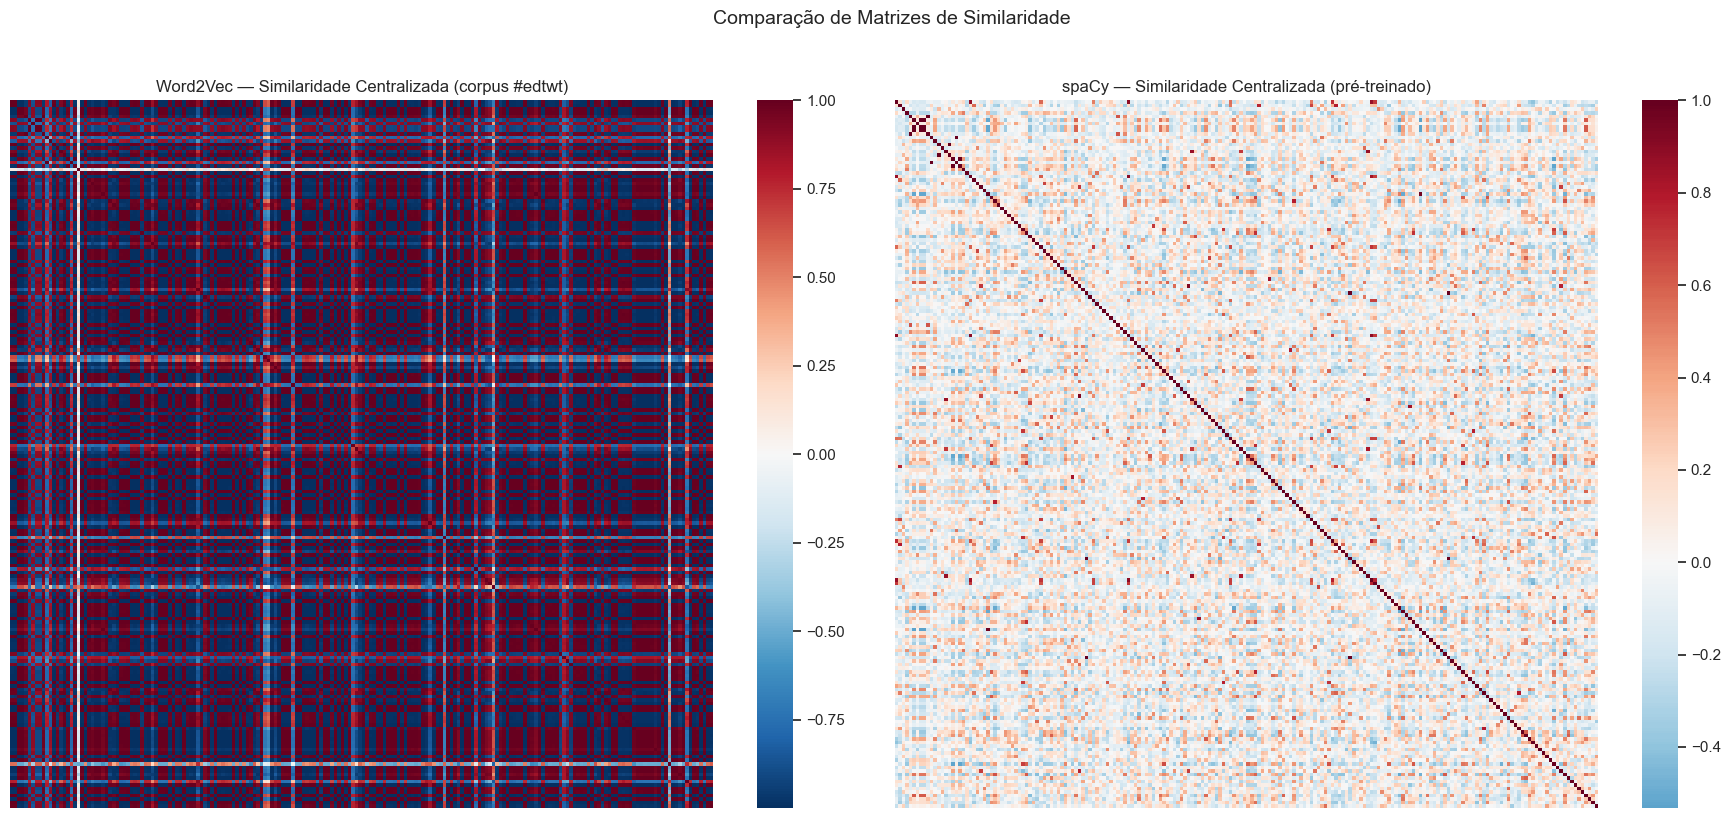

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(sim_w2v, annot=False, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title('Word2Vec — Similaridade Centralizada (corpus #edtwt)', fontsize=12)

sns.heatmap(sim_spacy, annot=False, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title('spaCy — Similaridade Centralizada (pré-treinado)', fontsize=12)

plt.suptitle('Comparação de Matrizes de Similaridade', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()